<a href="https://colab.research.google.com/github/junseok-jay/AI_lab/blob/main/week9/vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# cuDNN을 사용하여 Convolution 연산 최적화 설정
cudnn.benchmark = True
plt.ion()   # interactive mode

In [72]:
import zipfile
import os

# ZIP 압축 해제하는 함수
def extract_zip_file(zip_file_path, extraction_path):
    """ZIP 파일을 지정된 경로에 압축 해제합니다."""
    os.makedirs(extraction_path, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)
        print(f"Successfully extracted {zip_file_path} to {extraction_path}")
    except FileNotFoundError:
        print(f"Error: The file '{zip_file_path}' was not found.")
        raise
    except zipfile.BadZipFile:
        print(f"Error: The file '{zip_file_path}' is not a valid zip file or is corrupted.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")
        raise

# 데이터셋을 로드하는 함수
def load_image_datasets(data_dir, data_transforms):
    """디렉토리에서 이미지 데이터셋을 로드합니다."""
    try:
        image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                                  data_transforms[x])
                          for x in ['train', 'val']}
        dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                                     shuffle=True, num_workers=2)
                      for x in ['train', 'val']}
        dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
        class_names = image_datasets['train'].classes
        return image_datasets, dataloaders, dataset_sizes, class_names
    except Exception as e:
        print(f"An error occurred during dataset loading: {e}")
        raise

# 파일 경로 정의
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/AI_lab/week9/sample_computer_vision.zip'
extraction_path = './data/sample_computer_vision'
data_dir = os.path.join(extraction_path, 'sample_computer_vision')

# 학습을 위한 데이터 증강 및 정규화
# 검증을 위한 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 데이터셋 압축 해제, 로딩
extract_zip_file(zip_file_path, extraction_path)
image_datasets, dataloaders, dataset_sizes, class_names = load_image_datasets(data_dir, data_transforms)

# 사용할 장치 (GPU 또는 CPU) 결정, cuda 사용
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Successfully extracted /content/drive/MyDrive/Colab Notebooks/AI_lab/week9/sample_computer_vision.zip to ./data/sample_computer_vision
Using cuda device


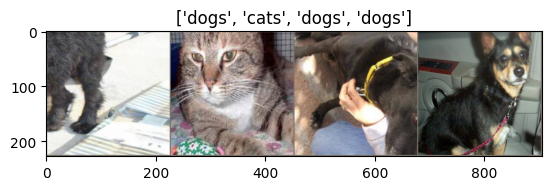

In [73]:
# 텐서 이미지를 표시하는 함수
def imshow(inp, title=None):
    """텐서 이미지를 표시합니다."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # 플롯 업테이트를 위한 대기


# 학습 데이터 배치 가져오기
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [74]:
# 모델 학습 함수
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [75]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()


    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)


            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])


                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [76]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
model_load = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_load.fc.in_features
model_load.fc = nn.Linear(num_ftrs, 2)

model_load = model_load.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_load.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [77]:
# 모델 학습 시작 (25 에포크)
my_model = train_model(model_load, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.4793 Acc: 0.7834
val Loss: 0.1582 Acc: 0.9500

Epoch 1/24
----------
train Loss: 0.5676 Acc: 0.8034
val Loss: 0.1136 Acc: 0.9550

Epoch 2/24
----------
train Loss: 0.6215 Acc: 0.7794
val Loss: 0.6931 Acc: 0.7600

Epoch 3/24
----------
train Loss: 0.6167 Acc: 0.7774
val Loss: 0.1457 Acc: 0.9550

Epoch 4/24
----------
train Loss: 0.4692 Acc: 0.8174
val Loss: 0.1899 Acc: 0.9700

Epoch 5/24
----------
train Loss: 0.4575 Acc: 0.8204
val Loss: 0.2772 Acc: 0.9150

Epoch 6/24
----------
train Loss: 0.3678 Acc: 0.8413
val Loss: 0.1509 Acc: 0.9650

Epoch 7/24
----------
train Loss: 0.3150 Acc: 0.8473
val Loss: 0.1487 Acc: 0.9650

Epoch 8/24
----------
train Loss: 0.2773 Acc: 0.8822
val Loss: 0.1332 Acc: 0.9750

Epoch 9/24
----------
train Loss: 0.2917 Acc: 0.8872
val Loss: 0.1306 Acc: 0.9750

Epoch 10/24
----------
train Loss: 0.2573 Acc: 0.8852
val Loss: 0.1241 Acc: 0.9700

Epoch 11/24
----------
train Loss: 0.2233 Acc: 0.9042
val Loss: 0.1369 Acc: 0.9650

Ep

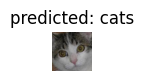

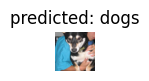

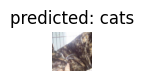

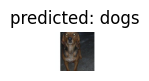

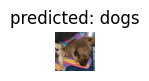

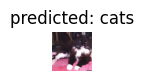

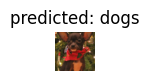

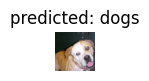

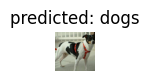

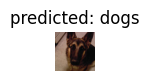

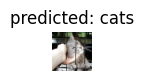

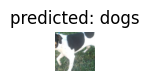

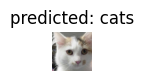

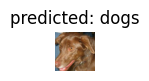

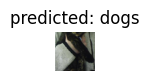

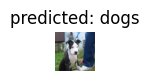

In [78]:
# 학습된 모델의 예측 결과를 시각화 (16개의 이미지)
visualize_model(my_model, num_images=16)

In [79]:
# ImageNet1K 데이터셋으로 사전 학습된 ResNet18 모델 로드
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')

for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [80]:
# 정의된 함수와 파라미터를 사용하여 컨볼루션 모델 학습 시작 (25 에포크)
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5070 Acc: 0.7745
val Loss: 0.1194 Acc: 0.9700

Epoch 1/24
----------
train Loss: 0.4618 Acc: 0.8024
val Loss: 0.1183 Acc: 0.9500

Epoch 2/24
----------
train Loss: 0.4368 Acc: 0.8293
val Loss: 0.1010 Acc: 0.9700

Epoch 3/24
----------
train Loss: 0.3722 Acc: 0.8373
val Loss: 0.0949 Acc: 0.9750

Epoch 4/24
----------
train Loss: 0.5025 Acc: 0.8034
val Loss: 0.1140 Acc: 0.9650

Epoch 5/24
----------
train Loss: 0.4096 Acc: 0.8343
val Loss: 0.1124 Acc: 0.9650

Epoch 6/24
----------
train Loss: 0.4322 Acc: 0.8263
val Loss: 0.1438 Acc: 0.9600

Epoch 7/24
----------
train Loss: 0.3682 Acc: 0.8503
val Loss: 0.1269 Acc: 0.9750

Epoch 8/24
----------
train Loss: 0.3157 Acc: 0.8583
val Loss: 0.1346 Acc: 0.9650

Epoch 9/24
----------
train Loss: 0.3724 Acc: 0.8453
val Loss: 0.1049 Acc: 0.9800

Epoch 10/24
----------
train Loss: 0.3265 Acc: 0.8653
val Loss: 0.1160 Acc: 0.9800

Epoch 11/24
----------
train Loss: 0.3267 Acc: 0.8593
val Loss: 0.1046 Acc: 0.9750

Ep

In [81]:
# 단일 이미지에 대한 모델 예측을 시각화하는 함수
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    # 이미지 로드 및 전처리
    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

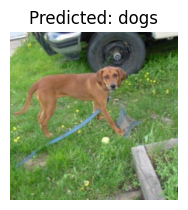

In [82]:
# 컨볼루션 모델을 사용하여 특정 이미지에 대한 예측 시각화
img_path='/content/data/sample_computer_vision/sample_computer_vision/val/dogs/dog.4021.jpg'

visualize_model_predictions(model_conv, img_path)

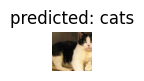

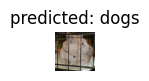

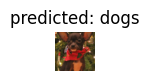

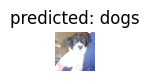

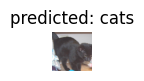

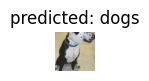

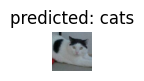

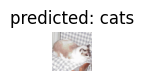

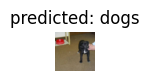

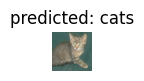

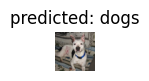

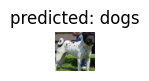

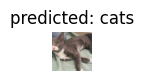

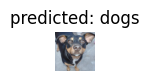

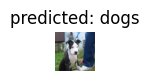

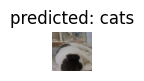

In [83]:
# 컨볼루션 모델을 사용하여 여러 이미지에 대한 예측 시각화
visualize_model(model_conv, num_images=16)